In [1]:
import pandas as pd

df = pd.read_csv("Dry_Eye_Dataset.csv")

print(df.shape)
print(df.columns)
df.head()

(20000, 26)
Index(['Gender', 'Age', 'Sleep duration', 'Sleep quality', 'Stress level',
       'Blood pressure', 'Heart rate', 'Daily steps', 'Physical activity',
       'Height', 'Weight', 'Sleep disorder', 'Wake up during night',
       'Feel sleepy during day', 'Caffeine consumption', 'Alcohol consumption',
       'Smoking', 'Medical issue', 'Ongoing medication',
       'Smart device before bed', 'Average screen time', 'Blue-light filter',
       'Discomfort Eye-strain', 'Redness in eye',
       'Itchiness/Irritation in eye', 'Dry Eye Disease'],
      dtype='object')


,Gender,Age,Sleep duration,Sleep quality,Stress level,Blood pressure,Heart rate,Daily steps,Physical activity,Height,...,Smoking,Medical issue,Ongoing medication,Smart device before bed,Average screen time,Blue-light filter,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye,Dry Eye Disease
0,F,24,9.5,2,1,137/89,67,3000,31,161,...,N,Y,Y,N,8.7,N,Y,Y,N,Y
1,M,39,9.6,2,3,108/64,60,12000,74,164,...,N,Y,Y,N,9.6,Y,N,N,Y,Y
2,F,45,5.4,1,5,134/81,95,12000,93,179,...,N,N,N,Y,4.0,N,Y,N,N,N
3,F,45,5.4,4,5,110/90,78,19000,32,160,...,N,Y,N,N,7.6,N,Y,N,Y,N
4,F,42,5.7,3,2,99/67,72,4000,173,179,...,N,Y,N,N,3.5,N,Y,Y,N,Y


In [2]:
# Dataset information

print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

df.describe()

Shape: (20000, 26)

Missing Values:
Gender                         0
Age                            0
Sleep duration                 0
Sleep quality                  0
Stress level                   0
Blood pressure                 0
Heart rate                     0
Daily steps                    0
Physical activity              0
Height                         0
Weight                         0
Sleep disorder                 0
Wake up during night           0
Feel sleepy during day         0
Caffeine consumption           0
Alcohol consumption            0
Smoking                        0
Medical issue                  0
Ongoing medication             0
Smart device before bed        0
Average screen time            0
Blue-light filter              0
Discomfort Eye-strain          0
Redness in eye                 0
Itchiness/Irritation in eye    0
Dry Eye Disease                0
dtype: int64

Duplicates:
0

Data Types:
Gender                          object
Age                       

,Age,Sleep duration,Sleep quality,Stress level,Heart rate,Daily steps,Physical activity,Height,Weight,Average screen time
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,31.422800,6.998245,2.997250,2.993750,79.912200,10536.900000,90.069750,174.865900,74.891850,5.519885
std,8.103717,1.731723,1.412283,1.407235,11.808279,5752.729186,52.317283,14.719903,14.733839,2.606305
min,18.000000,4.000000,1.000000,1.000000,60.000000,1000.000000,0.000000,150.000000,50.000000,1.000000
25%,24.000000,5.500000,2.000000,2.000000,70.000000,6000.000000,45.000000,162.000000,62.000000,3.300000
50%,31.000000,7.000000,3.000000,3.000000,80.000000,11000.000000,91.000000,175.000000,75.000000,5.500000
75%,39.000000,8.500000,4.000000,4.000000,90.000000,16000.000000,135.000000,188.000000,88.000000,7.800000
max,45.000000,10.000000,5.000000,5.000000,100.000000,20000.000000,180.000000,200.000000,100.000000,10.000000


In [3]:
# Convert Blood Pressure into two columns

df[['Systolic_BP', 'Diastolic_BP']] = df['Blood pressure'].str.split('/', expand=True)

df['Systolic_BP'] = df['Systolic_BP'].astype(int)
df['Diastolic_BP'] = df['Diastolic_BP'].astype(int)

# Drop original blood pressure column

df.drop('Blood pressure', axis=1, inplace=True)

print(df.head())

  Gender  Age  Sleep duration  Sleep quality  Stress level  Heart rate  \
0      F   24             9.5              2             1          67   
1      M   39             9.6              2             3          60   
2      F   45             5.4              1             5          95   
3      F   45             5.4              4             5          78   
4      F   42             5.7              3             2          72   

   Daily steps  Physical activity  Height  Weight  ... Ongoing medication  \
0         3000                 31     161      69  ...                  Y   
1        12000                 74     164      87  ...                  Y   
2        12000                 93     179      94  ...                  N   
3        19000                 32     160      77  ...                  N   
4         4000                173     179      99  ...                  N   

  Smart device before bed Average screen time Blue-light filter  \
0                       N

In [4]:
# Screen-to-sleep ratio

df['Screen_Sleep_Ratio'] = df['Average screen time'] / df['Sleep duration']

# BMI

df['BMI'] = df['Weight'] / ((df['Height']/100)**2)

# Lifestyle Risk Score

df['Lifestyle_Risk_Score'] = (
    df['Stress level']
    + df['Average screen time']
    - df['Sleep quality']
)

In [5]:
df[['BMI','Screen_Sleep_Ratio','Lifestyle_Risk_Score']].head()

,BMI,Screen_Sleep_Ratio,Lifestyle_Risk_Score
0,26.619343,0.915789,7.7
1,32.346817,1.000000,10.6
2,29.337411,0.740741,8.0
3,30.078125,1.407407,8.6
4,30.897912,0.614035,2.5


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,Gender,Age,Sleep duration,Sleep quality,Stress level,Heart rate,Daily steps,Physical activity,Height,Weight,...,Blue-light filter,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye,Dry Eye Disease,Systolic_BP,Diastolic_BP,Screen_Sleep_Ratio,BMI,Lifestyle_Risk_Score
0,0,24,9.5,2,1,67,3000,31,161,69,...,0,1,1,0,1,137,89,0.915789,26.619343,7.7
1,1,39,9.6,2,3,60,12000,74,164,87,...,1,0,0,1,1,108,64,1.000000,32.346817,10.6
2,0,45,5.4,1,5,95,12000,93,179,94,...,0,1,0,0,0,134,81,0.740741,29.337411,8.0
3,0,45,5.4,4,5,78,19000,32,160,77,...,0,1,0,1,0,110,90,1.407407,30.078125,8.6
4,0,42,5.7,3,2,72,4000,173,179,99,...,0,1,1,0,1,99,67,0.614035,30.897912,2.5


In [7]:
print(df.dtypes)

Gender                           int64
Age                              int64
Sleep duration                 float64
Sleep quality                    int64
Stress level                     int64
Heart rate                       int64
Daily steps                      int64
Physical activity                int64
Height                           int64
Weight                           int64
Sleep disorder                   int64
Wake up during night             int64
Feel sleepy during day           int64
Caffeine consumption             int64
Alcohol consumption              int64
Smoking                          int64
Medical issue                    int64
Ongoing medication               int64
Smart device before bed          int64
Average screen time            float64
Blue-light filter                int64
Discomfort Eye-strain            int64
Redness in eye                   int64
Itchiness/Irritation in eye      int64
Dry Eye Disease                  int64
Systolic_BP              

In [8]:
print(df.dtypes)

Gender                           int64
Age                              int64
Sleep duration                 float64
Sleep quality                    int64
Stress level                     int64
Heart rate                       int64
Daily steps                      int64
Physical activity                int64
Height                           int64
Weight                           int64
Sleep disorder                   int64
Wake up during night             int64
Feel sleepy during day           int64
Caffeine consumption             int64
Alcohol consumption              int64
Smoking                          int64
Medical issue                    int64
Ongoing medication               int64
Smart device before bed          int64
Average screen time            float64
Blue-light filter                int64
Discomfort Eye-strain            int64
Redness in eye                   int64
Itchiness/Irritation in eye      int64
Dry Eye Disease                  int64
Systolic_BP              

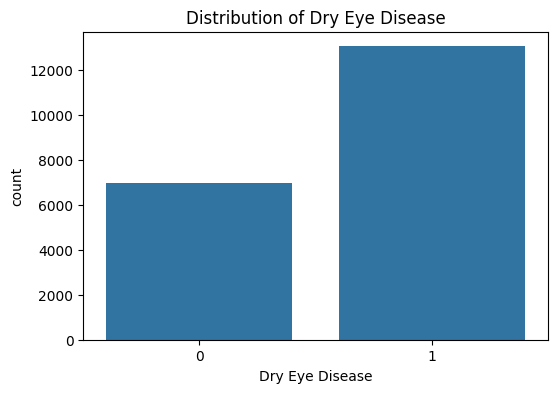

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='Dry Eye Disease', data=df)
plt.title('Distribution of Dry Eye Disease')
plt.show()

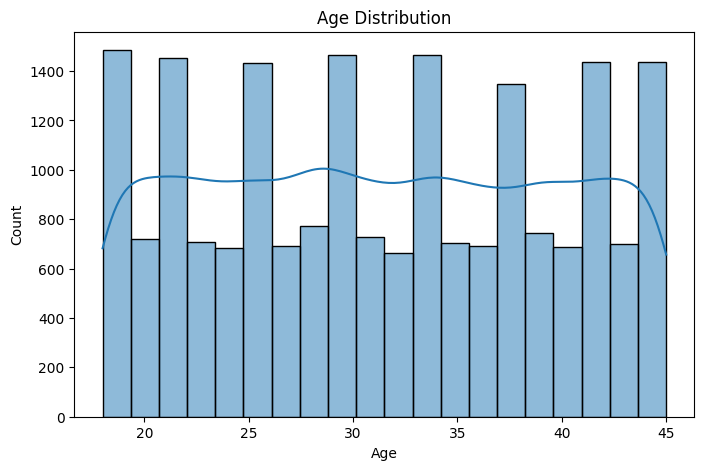

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

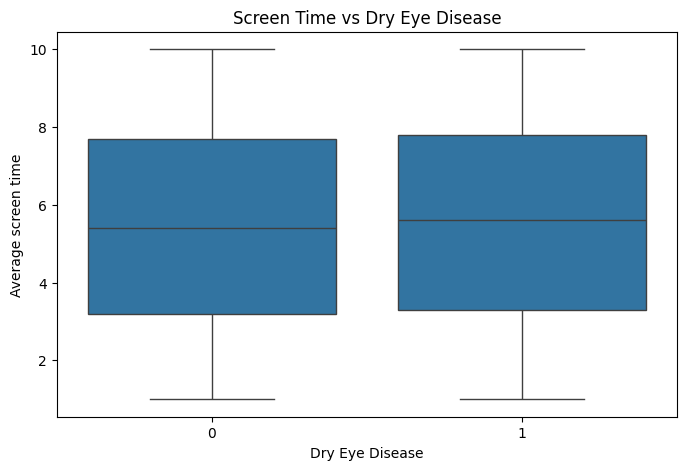

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Dry Eye Disease',
            y='Average screen time',
            data=df)
plt.title('Screen Time vs Dry Eye Disease')
plt.show()

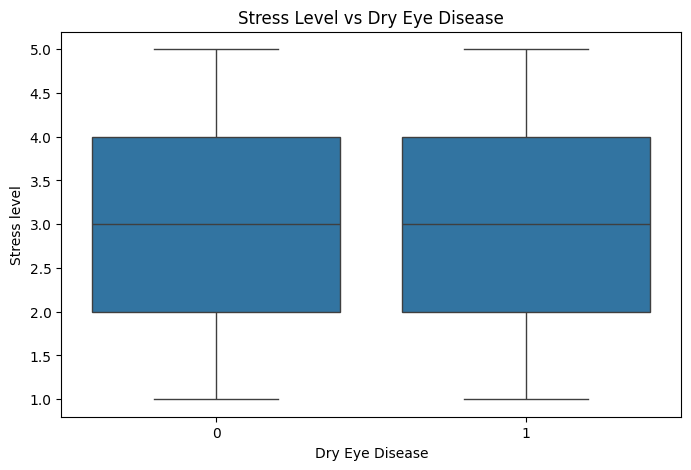

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Dry Eye Disease',
            y='Stress level',
            data=df)
plt.title('Stress Level vs Dry Eye Disease')
plt.show()

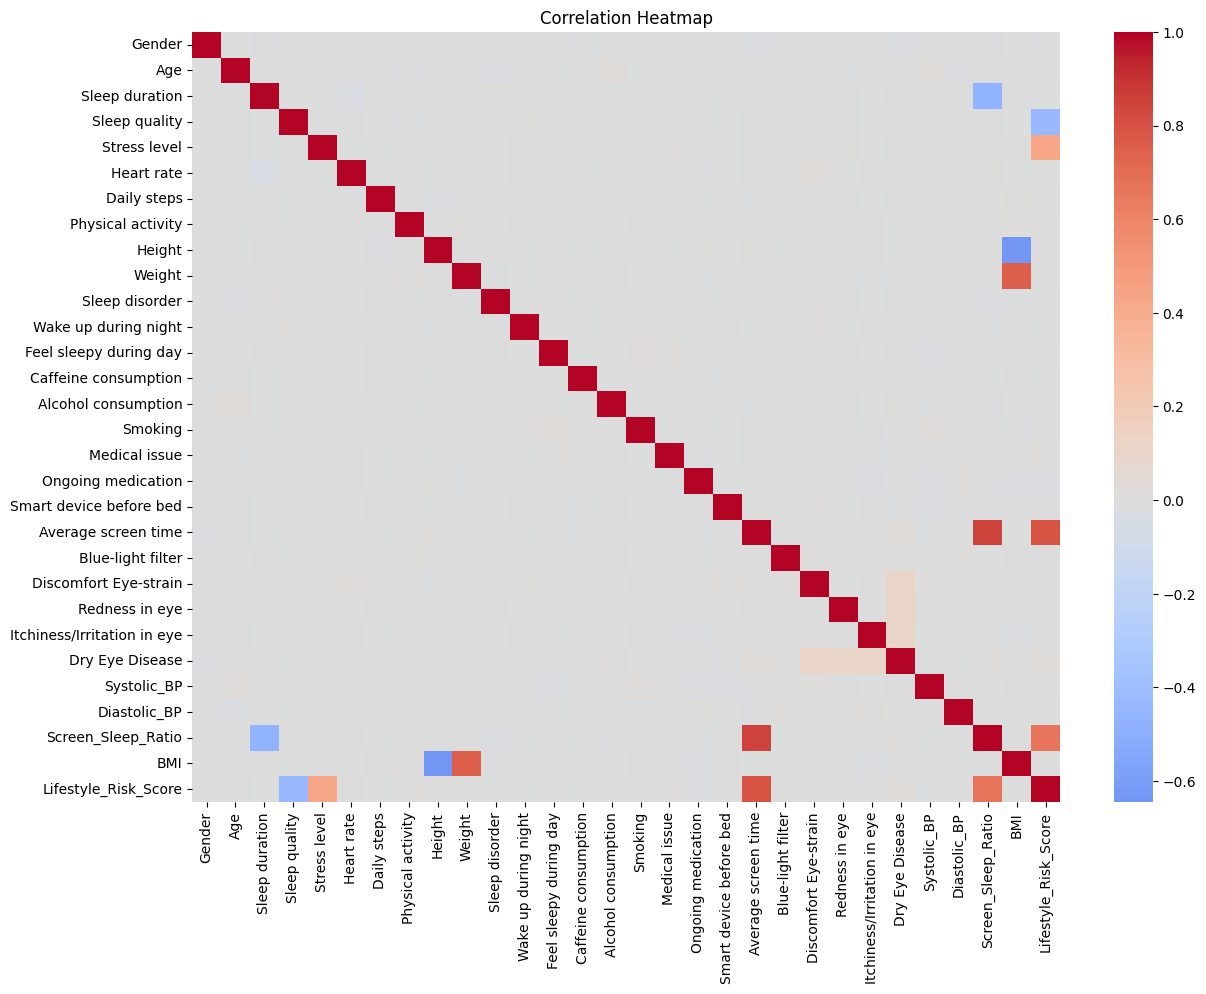

In [13]:
plt.figure(figsize=(14,10))

corr = df.corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')
plt.show()

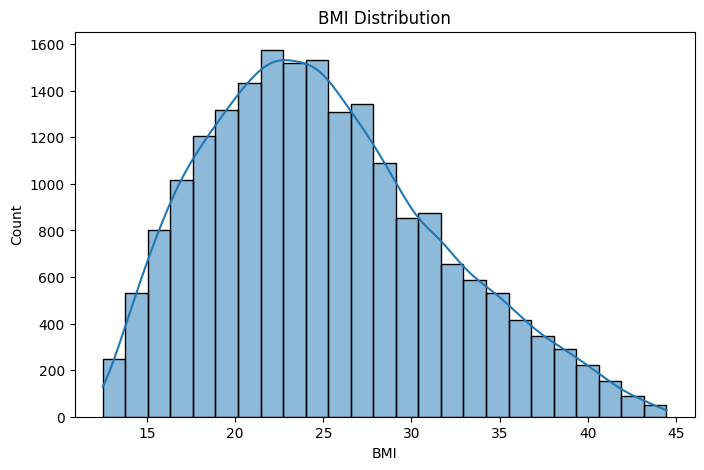

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['BMI'], bins=25, kde=True)
plt.title('BMI Distribution')
plt.show()

In [15]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

X = df.drop('Dry Eye Disease', axis=1)
y = df['Dry Eye Disease']

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=10
)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Top Features:")
print(selected_features)

Top Features:
Index(['Height', 'Sleep disorder', 'Wake up during night',
       'Caffeine consumption', 'Alcohol consumption', 'Discomfort Eye-strain',
       'Redness in eye', 'Itchiness/Irritation in eye', 'Diastolic_BP',
       'Lifestyle_Risk_Score'],
      dtype='object')


In [16]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

X = df.drop('Dry Eye Disease', axis=1)
y = df['Dry Eye Disease']

selector = SelectKBest(mutual_info_classif, k=10)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Top 10 Features:")
for feature in selected_features:
    print(feature)

Top 10 Features:
Gender
Daily steps
Smoking
Smart device before bed
Average screen time
Blue-light filter
Discomfort Eye-strain
Redness in eye
Itchiness/Irritation in eye
Diastolic_BP


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Dry Eye Disease', axis=1)
y = df['Dry Eye Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(16000, 29)
(4000, 29)


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.6915
              precision    recall  f1-score   support

           0       0.61      0.15      0.25      1307
           1       0.70      0.95      0.81      2693

    accuracy                           0.69      4000
   macro avg       0.65      0.55      0.53      4000
weighted avg       0.67      0.69      0.62      4000



In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.69675
              precision    recall  f1-score   support

           0       0.60      0.22      0.32      1307
           1       0.71      0.93      0.80      2693

    accuracy                           0.70      4000
   macro avg       0.65      0.57      0.56      4000
weighted avg       0.67      0.70      0.65      4000



In [20]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Accuracy: 0.7005
              precision    recall  f1-score   support

           0       0.61      0.22      0.33      1307
           1       0.71      0.93      0.81      2693

    accuracy                           0.70      4000
   macro avg       0.66      0.58      0.57      4000
weighted avg       0.68      0.70      0.65      4000



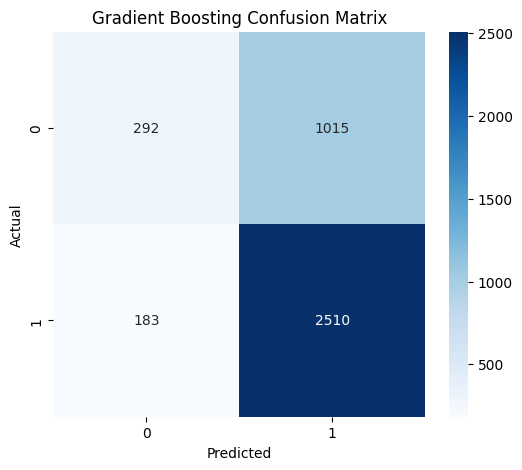

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Gradient Boosting Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

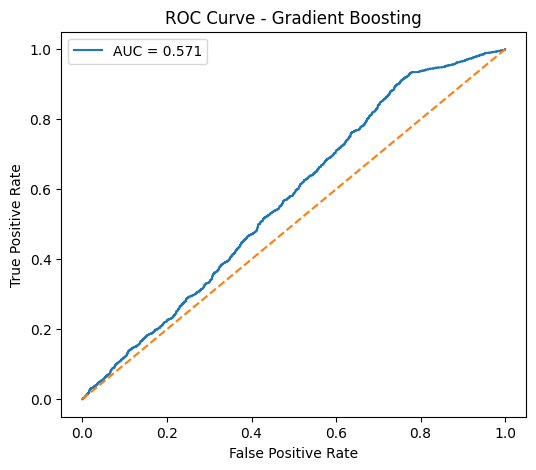

AUC Score: 0.5712972309688953


In [22]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = gb.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boosting')
plt.legend()

plt.show()

print("AUC Score:", auc)

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[50,100,200],
    'learning_rate':[0.01,0.05,0.1],
    'max_depth':[3,5]
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best Score:")
print(grid.best_score_)

Best Parameters:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Best Score:
0.697125


In [25]:
import joblib

joblib.dump(gb, 'dry_eye_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [27]:
from google.colab import files

files.download('dry_eye_model.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
{
 'learning_rate': 0.01,
 'max_depth': 3,
 'n_estimators': 100
}

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}

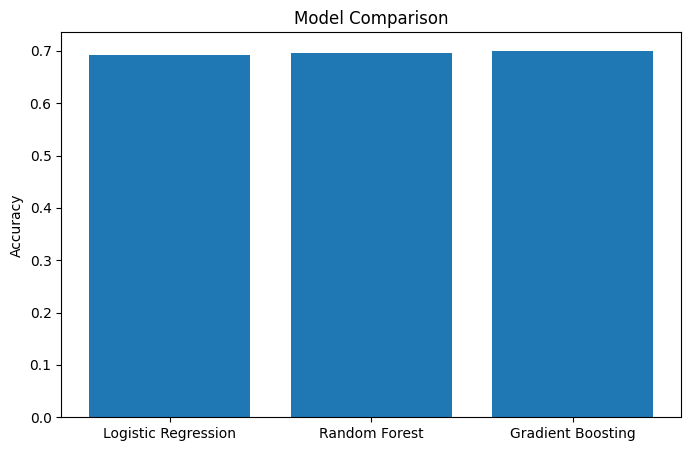

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy':[
        0.6915,
        0.69675,
        0.7005
    ]
})

plt.figure(figsize=(8,5))
plt.bar(results['Model'], results['Accuracy'])

plt.ylabel('Accuracy')
plt.title('Model Comparison')

plt.show()

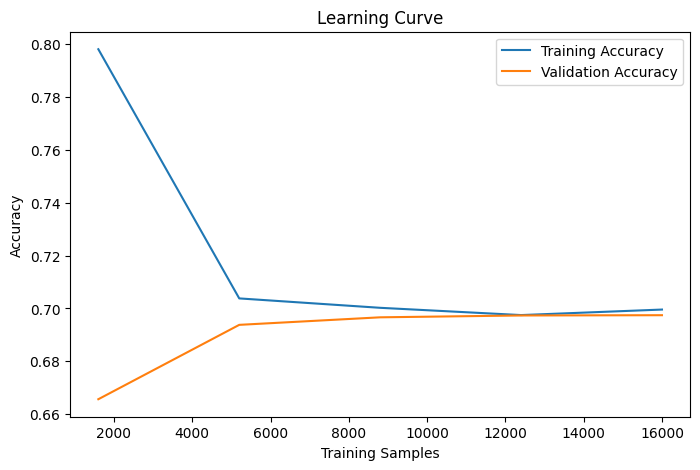

In [30]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    gb,
    X,
    y,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, label='Training Accuracy')
plt.plot(train_sizes, test_mean, label='Validation Accuracy')

plt.xlabel('Training Samples')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()

plt.show()

In [33]:
from google.colab import files

files.download('dry_eye_model.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>